In [53]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [7]:
BATCH_SIZE = 32
IMAGE_SIZE=256
CHANNELS=3
EPOCHS = 50

In [9]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


In [10]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

(32, 256, 256, 3)
[2 0 0 0 1 1 2 0 0 1 2 0 1 0 1 1 1 1 0 0 0 1 0 0 0 0 2 0 1 2 0 1]


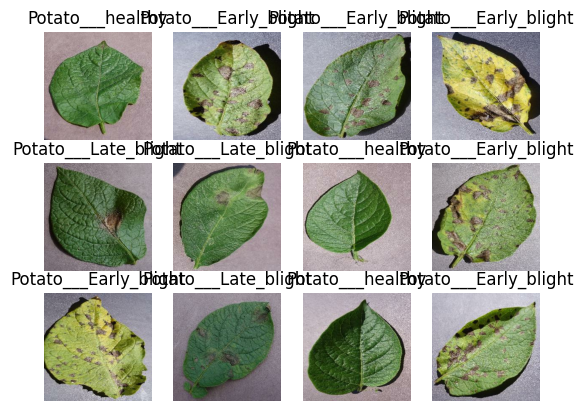

In [15]:
for image_batch, labels_batch in dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())
    for i in range(12):
        plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

In [16]:
train_size = 0.8
len(dataset)*train_size

54.400000000000006

In [17]:
test_ds = dataset.skip(54)
len(test_ds)

14

In [23]:
val_ds = test_ds.take(6)
len(val_ds)

6

In [24]:
test_ds = test_ds.skip(6)
len(test_ds)

8

In [25]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert(train_split + val_split + test_split) == 1
    
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
        
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    test_size = int(test_split * ds_size)
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
        
    return train_ds,val_ds,test_ds

In [26]:
train_ds,val_ds,test_ds = get_dataset_partitions_tf(dataset)

In [27]:
train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [29]:
for image_batch, label_batch in dataset.take(1):
    print(image_batch[0].numpy()/255)

[[[0.56078434 0.52156866 0.5176471 ]
  [0.5294118  0.49019608 0.4862745 ]
  [0.56078434 0.52156866 0.5176471 ]
  ...
  [0.68235296 0.64705884 0.65882355]
  [0.6745098  0.6392157  0.6509804 ]
  [0.6666667  0.6313726  0.6431373 ]]

 [[0.5372549  0.49803922 0.49411765]
  [0.5294118  0.49019608 0.4862745 ]
  [0.5294118  0.49019608 0.4862745 ]
  ...
  [0.6862745  0.6509804  0.6627451 ]
  [0.68235296 0.64705884 0.65882355]
  [0.6745098  0.6392157  0.6509804 ]]

 [[0.5529412  0.5137255  0.50980395]
  [0.5529412  0.5137255  0.50980395]
  [0.53333336 0.49411765 0.49019608]
  ...
  [0.6784314  0.6431373  0.654902  ]
  [0.67058825 0.63529414 0.64705884]
  [0.6666667  0.6313726  0.6431373 ]]

 ...

 [[0.4        0.36078432 0.39215687]
  [0.5058824  0.46666667 0.49803922]
  [0.43529412 0.39607844 0.42745098]
  ...
  [0.57254905 0.54509807 0.5764706 ]
  [0.5803922  0.5529412  0.58431375]
  [0.57254905 0.54509807 0.5764706 ]]

 [[0.39607844 0.35686275 0.3882353 ]
  [0.4627451  0.42352942 0.45490196]


In [34]:
resize_and_rescale = tf.keras.Sequential([
    layers.experimental.preprocessing.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.experimental.preprocessing.Rescaling(1.0/255),
])

In [35]:
data_augmentation = tf.keras.Sequential([
    layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
    layers.experimental.preprocessing.RandomRotation(0.2),
])

In [39]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3

model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32, kernel_size=(3,3), activation="relu",input_shape=input_shape),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3,3), activation="relu",input_shape=input_shape),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3,3), activation="relu",input_shape=input_shape),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3,3), activation="relu",input_shape=input_shape),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3,3), activation="relu",input_shape=input_shape),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3,3), activation="relu",input_shape=input_shape),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation=tf.nn.relu),
    layers.Dense(n_classes, activation='softmax')
])
model.build(input_shape=input_shape)

In [40]:
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_2 (Sequential)   (32, 256, 256, 3)         0         
                                                                 
 sequential_3 (Sequential)   (32, 256, 256, 3)         0         
                                                                 
 conv2d_12 (Conv2D)          (32, 254, 254, 32)        896       
                                                                 
 max_pooling2d_12 (MaxPooli  (32, 127, 127, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_13 (Conv2D)          (32, 125, 125, 64)        18496     
                                                                 
 max_pooling2d_13 (MaxPooli  (32, 62, 62, 64)          0         
 ng2D)                                                

In [41]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
                metrics=['accuracy'])

In [43]:
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=EPOCHS
)

Epoch 1/50
54/54 [==============================] - 53s 958ms/step - loss: 0.2570 - accuracy: 0.8920 - val_loss: 0.2422 - val_accuracy: 0.8854
Epoch 2/50
54/54 [==============================] - 135s 3s/step - loss: 0.2382 - accuracy: 0.9061 - val_loss: 0.3488 - val_accuracy: 0.8958
Epoch 3/50
54/54 [==============================] - 213s 4s/step - loss: 0.2015 - accuracy: 0.9261 - val_loss: 0.2754 - val_accuracy: 0.8698
Epoch 4/50
54/54 [==============================] - 192s 3s/step - loss: 0.1387 - accuracy: 0.9489 - val_loss: 0.1786 - val_accuracy: 0.9427
Epoch 5/50
54/54 [==============================] - 228s 4s/step - loss: 0.1893 - accuracy: 0.9290 - val_loss: 0.1952 - val_accuracy: 0.9010
Epoch 6/50
54/54 [==============================] - 197s 4s/step - loss: 0.1216 - accuracy: 0.9572 - val_loss: 0.1185 - val_accuracy: 0.9479
Epoch 7/50
54/54 [==============================] - 243s 4s/step - loss: 0.1290 - accuracy: 0.9542 - val_loss: 0.1409 - val_accuracy: 0.9531
Epoch 8/50


In [44]:
len(test_ds)

8

In [45]:
scores = model.evaluate(test_ds)
scores

8/8 [==============================] - 2s 148ms/step - loss: 0.0047 - accuracy: 1.0000


[0.004698062315583229, 1.0]

In [46]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

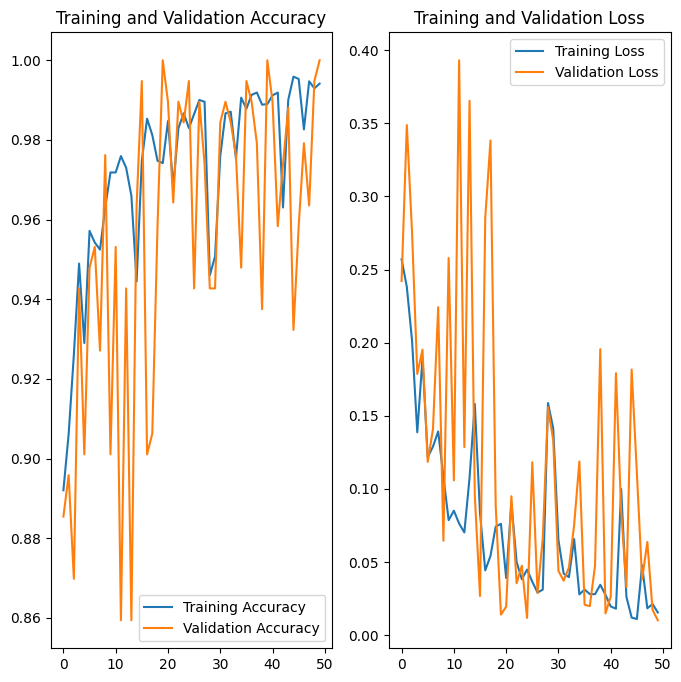

In [48]:
plt.figure(figsize=(8, 8))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Label 1
1/1 [==============================] - 1s 700ms/step
[5.1464629e-04 9.9948537e-01 1.7248412e-09]


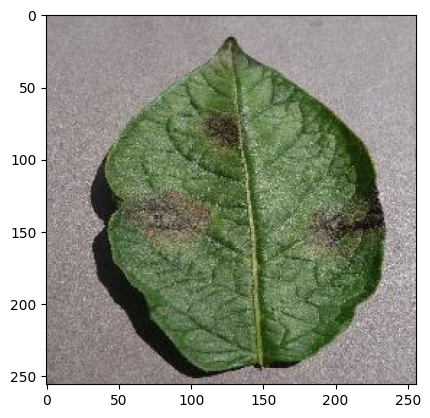

In [50]:
for images_batch, labels_batch in test_ds.take(1):
    first_image = images_batch[0].numpy().astype("uint8")
    plt.imshow(first_image)
    print("Label",labels_batch[0].numpy())
    
    batch_prediction = model.predict(images_batch)
    print(batch_prediction[0])

In [51]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0) 

    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 [==============================] - 0s 28ms/step


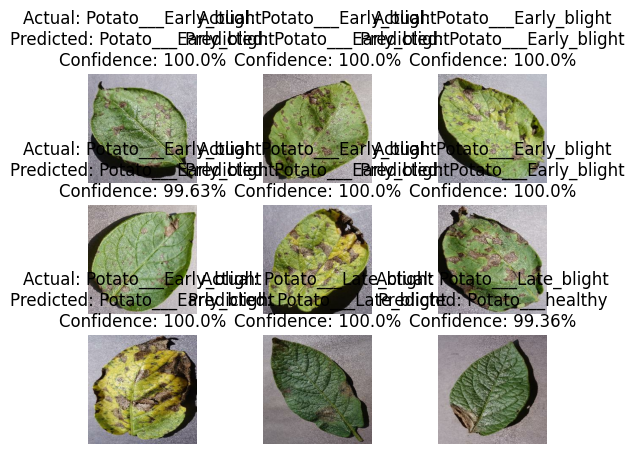

In [54]:
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        predicted_class, confidence = predict(model, images[i].numpy())
        
        actual_class = class_names[labels[i]]
        plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}\nConfidence: {confidence}%")
        plt.axis("off")

In [63]:
import os

models_dir = "models"
os.makedirs(models_dir, exist_ok=True)

existing_versions = [int(name) for name in os.listdir(models_dir) if name.isdigit()]
model_version = max(existing_versions, default=0) + 1

model.save(f"{models_dir}/{model_version}")

INFO:tensorflow:Assets written to: ../models/2\assets


INFO:tensorflow:Assets written to: ../models/2\assets


In [61]:
model_version

INFO:tensorflow:Assets written to: ../models/1\assets


INFO:tensorflow:Assets written to: ../models/1\assets
